IMU sample 개수: 5991


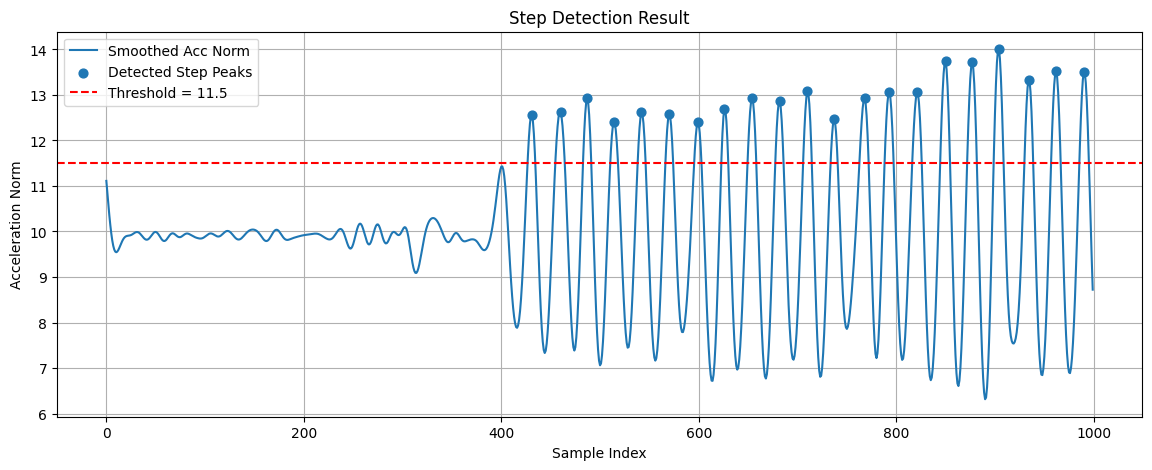

Detected steps: 176


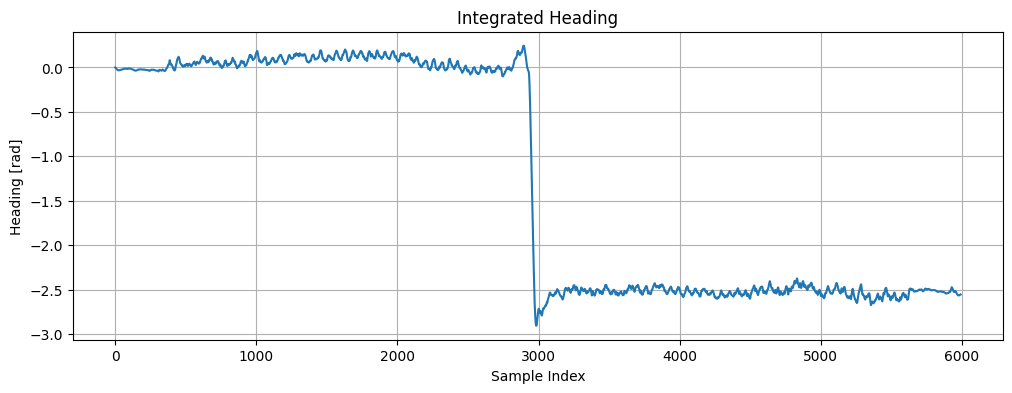

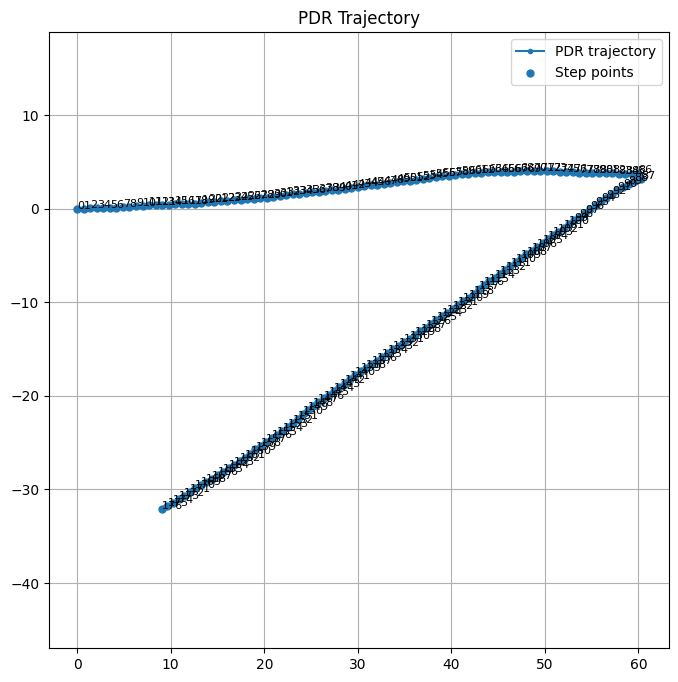

전체 WiFi 컬럼 개수: 293
실제 WiFi scan row 개수: 36

저장 완료: c:\Users\kimbo\NNL\workspace\vscode_workspace\고속수집기_라디오맵\temp_data\test_pdr_WiFi.csv
출력 shape: (177, 298)
PDR row 개수: 177
RSSI 컬럼 개수: 293
WiFi 처리 방식: nearest PDR step 배치 후 선형보간
-100 처리 방식: 보간하지 않고 미측정으로 유지

[WiFi - PDR time gap]
평균 gap sec: 0.6862499999999999
최대 gap sec: 7.741
WiFi가 배치된 PDR step 개수: 34

                      time  step_no  sample_idx         x         y  \
0  2026-07-09 20:40:18.812        0           0  0.000000  0.000000   
1  2026-07-09 20:40:27.417        1         431  0.699710  0.020148   
2  2026-07-09 20:40:27.996        2         460  1.398721  0.057340   
3  2026-07-09 20:40:28.536        3         487  2.098619  0.069290   
4  2026-07-09 20:40:29.076        4         514  2.798500  0.082187   

   WIFI_24:f2:7f:ff:61:13/eduroam  \
0                      -61.000000   
1                      -61.000000   
2                      -59.000000   
3                      -59.650211   
4                      -60.30042

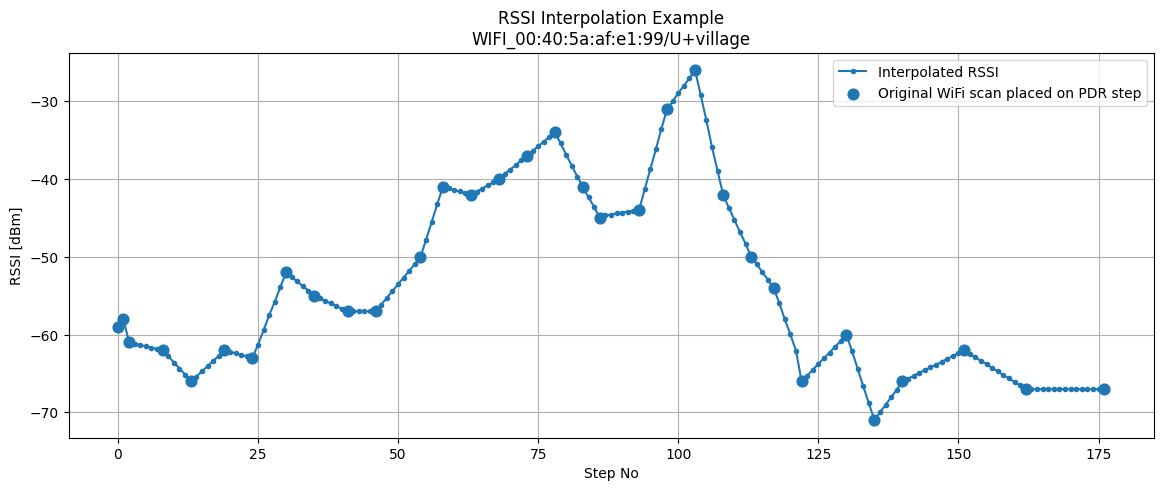

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from scipy.signal import butter, filtfilt, find_peaks


# ============================================================
# 사용자 설정
# ============================================================
BASE_DIR = os.getcwd()

IMU_DATA_PATH = os.path.join(BASE_DIR, "data", "20260709_204218_PDR_RF.csv")

OUTPUT_DATA_PATH = os.path.join(BASE_DIR, "temp_data")
OUTPUT_DATA_NAME = "test_pdr_WiFi.csv"

STEP_LENGTH = 0.7
FS = 50

MISSING_RSSI = -100

# WiFi scan time과 PDR step time 사이 허용 최대 시간 차이
# None이면 무조건 가장 가까운 PDR step에 배치
MAX_WIFI_GAP_SEC = None

# WiFi 컬럼 prefix
WIFI_PREFIX = "WIFI_"


# ============================================================
# 센서 데이터 로드
# ============================================================
def load_sensor(file_path):
    df = pd.read_csv(file_path)

    df["time"] = pd.to_datetime(
        df["time"],
        format="%Y-%m-%d %H:%M:%S.%f",
        errors="coerce"
    )

    df = df.dropna(subset=["time"]).reset_index(drop=True)

    start_dt = df["time"].iloc[0]
    df["Elapsed Time"] = (df["time"] - start_dt).dt.total_seconds()

    return df


# ============================================================
# PDR 수행
# ============================================================
def pdr(df, fs=50, step_length=0.7):
    # ------------------------------------------------------------
    # 1. Step Detection
    # ------------------------------------------------------------
    acc_norm = np.sqrt(
        df["acc_x"] ** 2 +
        df["acc_y"] ** 2 +
        df["acc_z"] ** 2
    )

    nyquist = 0.5 * fs
    normal_cutoff = 3.0 / nyquist

    b, a = butter(4, normal_cutoff, btype="low", analog=False)
    acc_norm_smoothed = filtfilt(b, a, acc_norm)

    print("IMU sample 개수:", len(acc_norm_smoothed))

    height = 11.5

    peaks, _ = find_peaks(
        acc_norm_smoothed,
        height=height,
        distance=20
    )

    plot_start = 0
    plot_end = min(1000, len(acc_norm_smoothed))

    plot_peaks = peaks[
        (peaks >= plot_start) &
        (peaks < plot_end)
    ]

    plt.figure(figsize=(14, 5))

    plt.plot(
        np.arange(plot_start, plot_end),
        acc_norm_smoothed[plot_start:plot_end],
        label="Smoothed Acc Norm"
    )

    plt.scatter(
        plot_peaks,
        acc_norm_smoothed[plot_peaks],
        s=40,
        label="Detected Step Peaks",
        zorder=3
    )

    plt.axhline(
        y=height,
        linestyle="--",
        c="red",
        label=f"Threshold = {height}"
    )

    plt.xlabel("Sample Index")
    plt.ylabel("Acceleration Norm")
    plt.title("Step Detection Result")
    plt.grid(True)
    plt.legend()
    plt.show()

    print("Detected steps:", len(peaks))

    # ------------------------------------------------------------
    # 2. Tilt Compensation
    # ------------------------------------------------------------
    ax = df["acc_x"].values
    ay = df["acc_y"].values
    az = df["acc_z"].values

    pitch = np.arctan2(ay, az)
    roll = np.arctan2(-ax, np.sqrt(ay ** 2 + az ** 2))

    gx = df["gyro_x"].values
    gy = df["gyro_y"].values
    gz = df["gyro_z"].values

    gyro_corr = np.zeros((len(df), 3))

    for i in range(len(df)):
        cos_p = np.cos(pitch[i])
        sin_p = np.sin(pitch[i])
        cos_r = np.cos(roll[i])
        sin_r = np.sin(roll[i])

        R_inv_pitch = np.array([
            [1,     0,      0],
            [0, cos_p, -sin_p],
            [0, sin_p,  cos_p]
        ])

        R_inv_roll = np.array([
            [ cos_r, 0, sin_r],
            [     0, 1,     0],
            [-sin_r, 0, cos_r]
        ])

        R_tilt = R_inv_roll @ R_inv_pitch

        gyro_vector = np.array([gx[i], gy[i], gz[i]])
        gyro_corr[i] = R_tilt @ gyro_vector

    gz_corr = gyro_corr[:, 2]

    # gyro_z가 rad/s 기준이라고 보고 적분
    heading = np.cumsum(gz_corr) / fs

    plt.figure(figsize=(12, 4))
    plt.plot(heading)
    plt.xlabel("Sample Index")
    plt.ylabel("Heading [rad]")
    plt.title("Integrated Heading")
    plt.grid(True)
    plt.show()

    # ------------------------------------------------------------
    # 3. Step마다 PDR 좌표 생성
    # ------------------------------------------------------------
    x_pos = [0.0]
    y_pos = [0.0]

    step_times = [df["time"].iloc[0]]
    step_sample_idx = [0]

    for step_count, step_idx in enumerate(peaks, start=1):
        psi = heading[step_idx]

        delta_x = step_length * np.cos(psi)
        delta_y = step_length * np.sin(psi)

        x_pos.append(x_pos[-1] + delta_x)
        y_pos.append(y_pos[-1] + delta_y)

        step_times.append(df["time"].iloc[step_idx])
        step_sample_idx.append(step_idx)

    x_pos = np.array(x_pos)
    y_pos = np.array(y_pos)

    pdr_df = pd.DataFrame({
        "time": step_times,
        "step_no": np.arange(len(x_pos)),
        "sample_idx": step_sample_idx,
        "x": x_pos,
        "y": y_pos
    })

    return x_pos, y_pos, pdr_df


# ============================================================
# PDR 경로 시각화
# ============================================================
def plot_pdr_trajectory(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    plt.figure(figsize=(8, 8))

    plt.plot(
        x,
        y,
        ".-",
        label="PDR trajectory"
    )

    plt.scatter(
        x,
        y,
        s=25,
        zorder=3,
        label="Step points"
    )

    for i in range(len(x)):
        plt.text(
            x[i],
            y[i],
            str(i),
            fontsize=8
        )

    plt.axis("equal")
    plt.grid(True)
    plt.legend()
    plt.title("PDR Trajectory")
    plt.show()


# ============================================================
# WiFi scan row 추출
# ============================================================
def extract_wifi_scan_df(df, wifi_prefix="WIFI_"):
    """
    PDR_RF.csv 안에서 WIFI_로 시작하는 컬럼만 추출한다.

    원본 구조:
        time, acc_x, acc_y, ..., WIFI_xxx, WIFI_xxx, ...

    출력 구조:
        time, WIFI_xxx, WIFI_xxx, ...

    WiFi 값이 하나라도 있는 row만 실제 WiFi scan row로 판단한다.
    """
    wifi_cols = [
        col for col in df.columns
        if str(col).startswith(wifi_prefix)
    ]

    if len(wifi_cols) == 0:
        raise ValueError(f"{wifi_prefix} 로 시작하는 WiFi 컬럼이 없습니다.")

    wifi_df = df[["time"] + wifi_cols].copy()

    for col in wifi_cols:
        wifi_df[col] = pd.to_numeric(wifi_df[col], errors="coerce")

    # WiFi RSSI가 하나라도 존재하는 row만 scan row로 사용
    has_wifi = wifi_df[wifi_cols].notna().any(axis=1)

    wifi_scan_df = wifi_df.loc[has_wifi].copy()
    wifi_scan_df = wifi_scan_df.sort_values("time").reset_index(drop=True)

    print("전체 WiFi 컬럼 개수:", len(wifi_cols))
    print("실제 WiFi scan row 개수:", len(wifi_scan_df))

    return wifi_scan_df, wifi_cols


# ============================================================
# WiFi scan을 가장 가까운 PDR step에 배치
# ============================================================
def place_wifi_scan_on_nearest_pdr(
    pdr_df,
    wifi_scan_df,
    wifi_cols,
    fill_value=-100,
    max_gap_sec=None
):
    """
    WiFi scan row를 가장 가까운 PDR step row에 배치한다.

    결과:
        PDR row 개수와 동일한 RSSI DataFrame 생성

    특징:
        - 실제 WiFi scan이 배치된 PDR row만 RSSI 값을 가짐
        - 나머지 PDR row는 NaN
        - 같은 PDR row에 여러 WiFi scan이 붙으면 AP별 평균
        - 평균 계산 시 -100은 제외
        - 특정 AP가 전부 NaN 또는 -100이면 -100으로 처리
    """
    pdr_base = pdr_df.copy()
    pdr_base["time"] = pd.to_datetime(pdr_base["time"])
    pdr_base = pdr_base.sort_values("time").reset_index(drop=True)

    wifi_scan_df = wifi_scan_df.copy()
    wifi_scan_df["time"] = pd.to_datetime(wifi_scan_df["time"])
    wifi_scan_df = wifi_scan_df.sort_values("time").reset_index(drop=True)

    placed_df = pd.DataFrame(
        np.nan,
        index=np.arange(len(pdr_base)),
        columns=wifi_cols
    )

    if len(wifi_scan_df) == 0:
        return placed_df, pd.DataFrame()

    pdr_times = pdr_base["time"].reset_index(drop=True)

    pdr_ns = pdr_times.astype("int64").to_numpy()
    wifi_ns = wifi_scan_df["time"].astype("int64").to_numpy()

    nearest_indices = []
    gap_seconds = []

    for wt in wifi_ns:
        insert_pos = np.searchsorted(pdr_ns, wt)

        candidates = []

        if insert_pos > 0:
            candidates.append(insert_pos - 1)

        if insert_pos < len(pdr_ns):
            candidates.append(insert_pos)

        candidates = np.array(candidates, dtype=int)

        diffs = np.abs(pdr_ns[candidates] - wt)

        nearest_idx = candidates[np.argmin(diffs)]
        gap_sec = np.min(diffs) / 1e9

        nearest_indices.append(nearest_idx)
        gap_seconds.append(gap_sec)

    wifi_scan_df["_nearest_pdr_idx"] = nearest_indices
    wifi_scan_df["_gap_sec"] = gap_seconds

    if max_gap_sec is not None:
        wifi_scan_df = wifi_scan_df[
            wifi_scan_df["_gap_sec"] <= max_gap_sec
        ].copy()

    # 여러 WiFi scan이 같은 PDR step에 붙는 경우 평균
    for pdr_idx, group in wifi_scan_df.groupby("_nearest_pdr_idx"):
        pdr_idx = int(pdr_idx)

        values = group[wifi_cols].copy()

        # WiFi scan row에서 NaN은 해당 AP 미측정으로 보고 -100 처리
        values = values.fillna(fill_value)

        # 평균 계산 시 -100은 제외
        values_for_mean = values.replace(fill_value, np.nan)

        avg_values = values_for_mean.mean(axis=0, skipna=True)

        # 해당 PDR step에 scan은 있었지만 특정 AP가 모두 미측정이면 -100
        all_missing_mask = values_for_mean.isna().all(axis=0)
        avg_values[all_missing_mask] = fill_value

        placed_df.loc[pdr_idx, wifi_cols] = avg_values

    gap_info_df = wifi_scan_df[
        ["time", "_nearest_pdr_idx", "_gap_sec"]
    ].copy()

    gap_info_df = gap_info_df.rename(columns={
        "time": "wifi_time",
        "_nearest_pdr_idx": "nearest_pdr_idx",
        "_gap_sec": "gap_sec"
    })

    return placed_df, gap_info_df


# ============================================================
# RSSI 선형보간
# -100도 missing으로 보고 보간
# ============================================================
def interpolate_rssi_without_minus100(
    placed_rssi_df,
    pdr_times,
    fill_value=-100
):
    """
    PDR step 사이에 비어 있는 RSSI를 선형보간한다.

    수정된 규칙:
        1. NaN은 missing으로 처리
        2. -100도 missing으로 처리
        3. 양쪽에 유효 RSSI가 있으면 그 사이를 선형보간
        4. 맨 앞 / 맨 뒤처럼 한쪽에만 유효 RSSI가 있으면 보간하지 않음
        5. 최종적으로 남은 NaN은 -100으로 채움
    """

    pdr_times = pd.to_datetime(pdr_times).reset_index(drop=True)

    # 시간 기반 보간을 위한 x축
    t_sec = (
        pdr_times - pdr_times.iloc[0]
    ).dt.total_seconds().to_numpy()

    result_df = pd.DataFrame(
        fill_value,
        index=placed_rssi_df.index,
        columns=placed_rssi_df.columns
    )

    for col in placed_rssi_df.columns:
        s = pd.to_numeric(
            placed_rssi_df[col],
            errors="coerce"
        ).copy()

        # 핵심 변경:
        # -100을 보간 금지값으로 두지 않고,
        # missing 값으로 처리
        s = s.replace(fill_value, np.nan)

        valid_mask = s.notna()
        valid_idx = np.where(valid_mask.to_numpy())[0]

        # 유효 RSSI가 없으면 전부 -100
        if len(valid_idx) == 0:
            continue

        # 유효 RSSI가 1개뿐이면 해당 위치만 살리고 나머지는 -100
        if len(valid_idx) == 1:
            result_df.loc[valid_idx, col] = s.iloc[valid_idx].values
            continue

        # 시간축을 index로 둔 Series 생성
        s_time = pd.Series(
            s.to_numpy(),
            index=t_sec
        )

        # 양쪽에 유효값이 있는 내부 구간만 선형보간
        s_interp = s_time.interpolate(
            method="index",
            limit_area="inside"
        )

        # 남은 NaN은 -100
        s_interp = s_interp.fillna(fill_value)

        result_df[col] = s_interp.to_numpy()

    return result_df


# ============================================================
# PDR + WiFi 선형보간 결합
# ============================================================
def merge_pdr_with_wifi_interpolation(
    raw_df,
    pdr_df,
    output_dir,
    output_name,
    wifi_prefix="WIFI_",
    fill_value=-100,
    max_gap_sec=None
):
    """
    처리 과정:
        1. raw_df에서 WIFI_ 컬럼 추출
        2. 실제 WiFi scan row만 추출
        3. WiFi scan을 가장 가까운 PDR step에 배치
        4. 비어 있는 PDR step의 RSSI를 선형보간
        5. -100은 보간하지 않음
        6. CSV 저장
    """
    pdr_base = pdr_df[
        ["time", "step_no", "sample_idx", "x", "y"]
    ].copy()

    pdr_base["time"] = pd.to_datetime(pdr_base["time"])
    pdr_base = pdr_base.sort_values("time").reset_index(drop=True)

    wifi_scan_df, wifi_cols = extract_wifi_scan_df(
        raw_df,
        wifi_prefix=wifi_prefix
    )

    placed_rssi_df, gap_info_df = place_wifi_scan_on_nearest_pdr(
        pdr_df=pdr_base,
        wifi_scan_df=wifi_scan_df,
        wifi_cols=wifi_cols,
        fill_value=fill_value,
        max_gap_sec=max_gap_sec
    )

    interpolated_rssi_df = interpolate_rssi_without_minus100(
        placed_rssi_df=placed_rssi_df,
        pdr_times=pdr_base["time"],
        fill_value=fill_value
    )

    merged = pd.concat(
        [
            pdr_base.reset_index(drop=True),
            interpolated_rssi_df.reset_index(drop=True)
        ],
        axis=1
    )

    merged["time"] = (
        merged["time"]
        .dt.strftime("%Y-%m-%d %H:%M:%S.%f")
        .str[:-3]
    )

    os.makedirs(output_dir, exist_ok=True)

    output_path = os.path.join(output_dir, output_name)
    merged.to_csv(output_path, index=False, encoding="utf-8-sig")

    print()
    print("저장 완료:", output_path)
    print("출력 shape:", merged.shape)
    print("PDR row 개수:", len(merged))
    print("RSSI 컬럼 개수:", len(wifi_cols))
    print("WiFi 처리 방식: nearest PDR step 배치 후 선형보간")
    print("-100 처리 방식: 보간하지 않고 미측정으로 유지")

    if len(gap_info_df) > 0:
        print()
        print("[WiFi - PDR time gap]")
        print("평균 gap sec:", gap_info_df["gap_sec"].mean())
        print("최대 gap sec:", gap_info_df["gap_sec"].max())
        print("WiFi가 배치된 PDR step 개수:", gap_info_df["nearest_pdr_idx"].nunique())

    return merged, placed_rssi_df, interpolated_rssi_df, gap_info_df


# ============================================================
# WiFi 보간 결과 확인용 Plot
# ============================================================
def plot_interpolation_example(
    placed_rssi_df,
    interpolated_rssi_df,
    pdr_df,
    target_col=None
):
    """
    특정 WiFi AP 하나에 대해
    원래 scan이 배치된 지점과 보간 결과를 비교한다.
    """
    if target_col is None:
        # 유효값이 가장 많은 AP 자동 선택
        valid_counts = (placed_rssi_df != MISSING_RSSI).sum(axis=0)
        valid_counts = valid_counts.sort_values(ascending=False)

        if len(valid_counts) == 0:
            print("Plot할 WiFi 컬럼이 없습니다.")
            return

        target_col = valid_counts.index[0]

    if target_col not in interpolated_rssi_df.columns:
        print("해당 WiFi 컬럼이 없습니다:", target_col)
        return

    step_no = pdr_df["step_no"].values

    placed = placed_rssi_df[target_col].replace(MISSING_RSSI, np.nan)
    interp = interpolated_rssi_df[target_col].replace(MISSING_RSSI, np.nan)

    plt.figure(figsize=(14, 5))

    plt.plot(
        step_no,
        interp,
        ".-",
        label="Interpolated RSSI"
    )

    plt.scatter(
        step_no,
        placed,
        s=60,
        zorder=3,
        label="Original WiFi scan placed on PDR step"
    )

    plt.xlabel("Step No")
    plt.ylabel("RSSI [dBm]")
    plt.title(f"RSSI Interpolation Example\n{target_col}")
    plt.grid(True)
    plt.legend()
    plt.show()


# ============================================================
# 실행
# ============================================================
df = load_sensor(IMU_DATA_PATH)

x, y, pdr_df = pdr(
    df,
    fs=FS,
    step_length=STEP_LENGTH
)

plot_pdr_trajectory(x, y)

df_pdr_wifi, placed_rssi_df, interpolated_rssi_df, gap_info_df = merge_pdr_with_wifi_interpolation(
    raw_df=df,
    pdr_df=pdr_df,
    output_dir=OUTPUT_DATA_PATH,
    output_name=OUTPUT_DATA_NAME,
    wifi_prefix=WIFI_PREFIX,
    fill_value=MISSING_RSSI,
    max_gap_sec=MAX_WIFI_GAP_SEC
)

print()
print(df_pdr_wifi.head())

# 보간 결과 예시 확인용 plot
plot_interpolation_example(
    placed_rssi_df=placed_rssi_df,
    interpolated_rssi_df=interpolated_rssi_df,
    pdr_df=pdr_df,
    target_col=None
)